In [277]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [278]:
# Download S&P500 constituents (top 10 stocks)
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'JPM', 'V', 'JNJ']

In [279]:
# Set date range
start_date = '2021-09-20'
end_date = '2026-03-21'
window = 60  # Rolling window for beta calculation # why use 60?

In [280]:
# Download data
print("Downloading data...")
stock_prices = yf.download(tickers, start=start_date, end=end_date, progress=False)['Close']
spy_prices = yf.download('^GSPC', start=start_date, end=end_date, progress=False)['Close']

In [281]:
# Calculate returns
stock_returns = stock_prices.pct_change().dropna()
market_returns = spy_prices.pct_change().dropna()

# Create equally weighted portfolio
weights = np.ones(len(tickers)) / len(tickers)
portfolio_returns = stock_returns.dot(weights)

In [282]:
# Calculate rolling beta of portfolio vs S&P500
def calculate_rolling_beta(portfolio_returns, market_returns, window):
    """Calculate rolling beta between portfolio and market"""
    rolling_cov = portfolio_returns.rolling(window).cov(market_returns)
    rolling_var = market_returns.rolling(window).var()
    rolling_beta = rolling_cov / rolling_var
    return rolling_beta

In [283]:
# Calculate rolling beta
print("Calculating rolling beta...")
rolling_beta = calculate_rolling_beta(portfolio_returns, market_returns, window)

# Display results
print(f"\nCurrent Portfolio Beta: {rolling_beta.iloc[-1, 0]:.3f}")
print(f"Average Beta (full period): {rolling_beta.mean().iloc[0]:.3f}")
print(f"Beta Range: [{rolling_beta.min().iloc[0]:.3f}, {rolling_beta.max().iloc[0]:.3f}]")

Calculating rolling beta...

Current Portfolio Beta: 1.063
Average Beta (full period): 1.288
Beta Range: [1.007, 1.491]


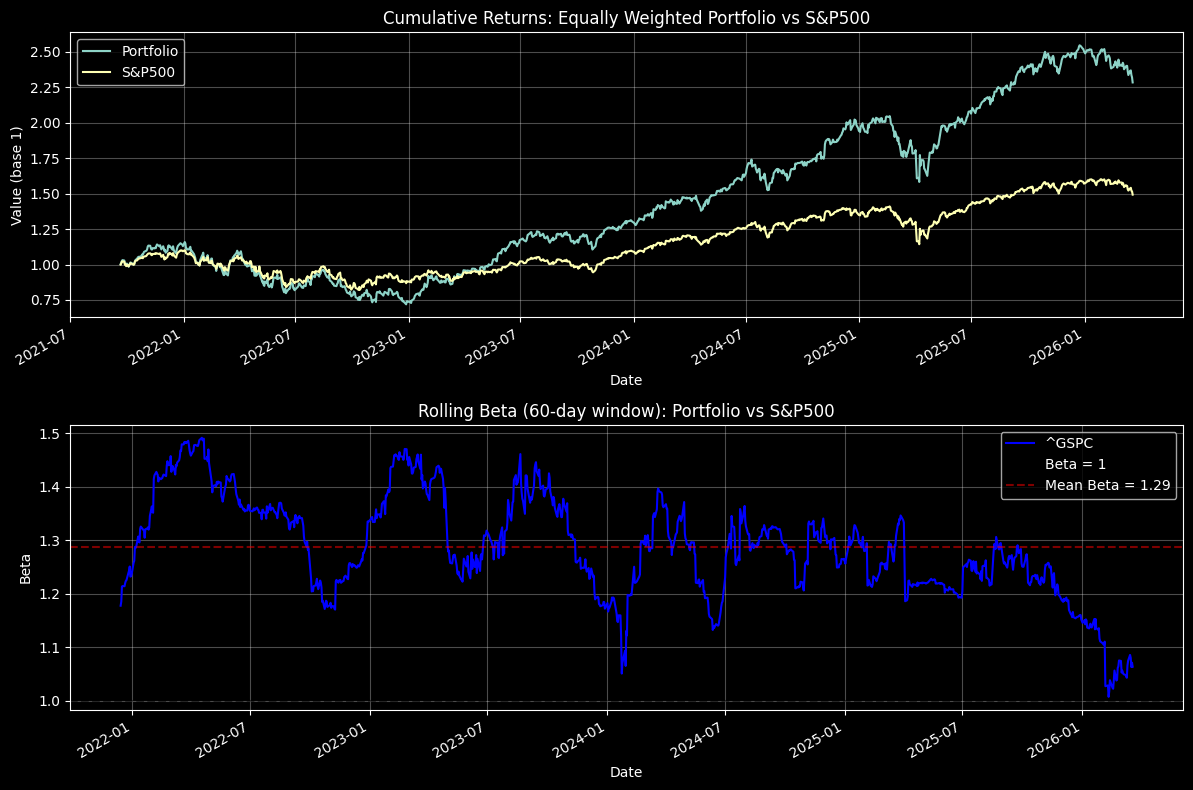

In [284]:
# Visualization
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Cumulative returns
cumulative_returns = pd.DataFrame({
    'Portfolio': (1 + portfolio_returns).cumprod(),
    'S&P500': (1 + market_returns).cumprod()['^GSPC']
})

cumulative_returns.plot(ax=axes[0])
axes[0].set_title('Cumulative Returns: Equally Weighted Portfolio vs S&P500')
axes[0].set_ylabel('Value (base 1)')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper left')

# Plot 2: Rolling beta
rolling_beta.plot(ax=axes[1], color='blue')
axes[1].axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Beta = 1')
axes[1].axhline(y=rolling_beta.mean().iloc[0], color='red', linestyle='--', alpha=0.5, label=f'Mean Beta = {rolling_beta.mean().iloc[0]:.2f}')
axes[1].set_title(f'Rolling Beta ({window}-day window): Portfolio vs S&P500')
axes[1].set_ylabel('Beta')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [285]:
# Summary statistics
print("\n=== PORTFOLIO STATISTICS ===")
print(f"Annual Return: {portfolio_returns.mean() * 252:.2%}")
print(f"Annual Volatility: {portfolio_returns.std() * np.sqrt(252):.2%}")
print(f"Correlation with S&P500: {portfolio_returns.corr(market_returns['^GSPC']):.3f}")


=== PORTFOLIO STATISTICS ===
Annual Return: 21.36%
Annual Volatility: 24.18%
Correlation with S&P500: 0.930


In [286]:
portfolio_returns = portfolio_returns.to_frame(name="EqualWeight")
# portfolio_returns.to_csv('../data/backtest/equal_weights_returns.csv')
portfolio_returns

,EqualWeight
Date,
2021-09-21,0.003277
2021-09-22,0.008659
2021-09-23,0.012665
2021-09-24,0.006258
2021-09-27,-0.002871
...,...
2026-03-16,0.012943
2026-03-17,0.000915
2026-03-18,-0.013811


In [287]:
# market_returns.to_csv('../data/backtest/market_returns.csv')
market_returns

Ticker,^GSPC
Date,
2021-09-21,-0.000812
2021-09-22,0.009520
2021-09-23,0.012135
2021-09-24,0.001461
2021-09-27,-0.002776
...,...
2026-03-16,0.010131
2026-03-17,0.002494
2026-03-18,-0.013608


In [288]:
combined_returns = pd.concat([market_returns, portfolio_returns], axis=1)
combined_returns.to_csv('../data/processed/combined_returns.csv',  float_format = "%.6f")

In [289]:
TRADING_DAYS = 252

def performance_stats(returns):
    """
    returns: pd.Series of daily returns
    """
    returns = returns.dropna()
    print(returns.head())
    ann_return =  returns.mean() * TRADING_DAYS
    ann_vol = returns.std() * np.sqrt(TRADING_DAYS)
    sharpe = ann_return / (ann_vol + 1e-12)

    return pd.Series({
        "Annualized Return": ann_return,
        "Annualized Volatility": ann_vol,
        "Sharpe Ratio": sharpe
    })


In [290]:
stats = pd.DataFrame({
    "EqualWeight": performance_stats(combined_returns["EqualWeight"]),
    "Benchmark (^GSPC)": performance_stats(combined_returns["^GSPC"])
})

stats

Date
2021-09-21    0.003277
2021-09-22    0.008659
2021-09-23    0.012665
2021-09-24    0.006258
2021-09-27   -0.002871
Name: EqualWeight, dtype: float64
Date
2021-09-21   -0.000812
2021-09-22    0.009520
2021-09-23    0.012135
2021-09-24    0.001461
2021-09-27   -0.002776
Name: ^GSPC, dtype: float64


,EqualWeight,Benchmark (^GSPC)
Annualized Return,0.213613,0.104562
Annualized Volatility,0.241798,0.173808
Sharpe Ratio,0.883436,0.601593
